In [2]:
%pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 8.5 MB/s  0:00:008.7 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.7 MB/s  0:00:01m 2.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 12.0 MB/s  0:00:00 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 14.9 MB/s  0:00:00.4 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 13.6 MB/s  0:00:00 20.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [seaborn]━ 10/12 [matplotlib]as]
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


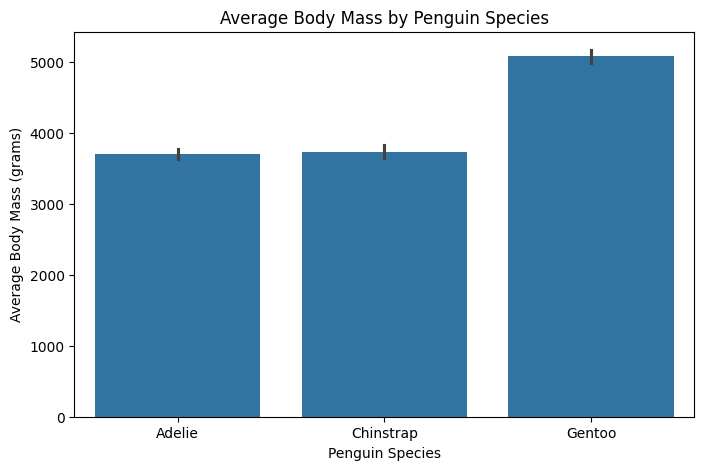

In [9]:
#Task 1 : Bar Chart: Compare a Category

plt.figure(figsize=(8, 5))

sns.barplot(x="species", y="body_mass_g", data=df)

plt.title("Average Body Mass by Penguin Species")
plt.xlabel("Penguin Species")
plt.ylabel("Average Body Mass (grams)")

plt.show()


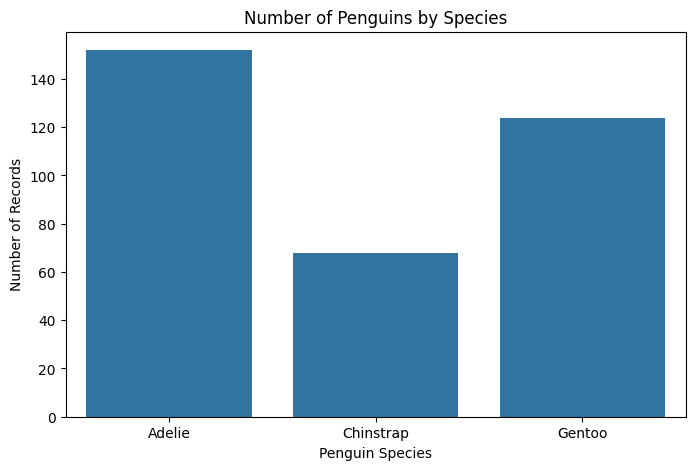

In [11]:
#Task 2 : Count Plot: Category Frequency
plt.figure(figsize=(8, 5))

sns.countplot(x="species", data=df)

plt.title("Number of Penguins by Species")
plt.xlabel("Penguin Species")
plt.ylabel("Number of Records")

plt.show()
# Adelie is the most common

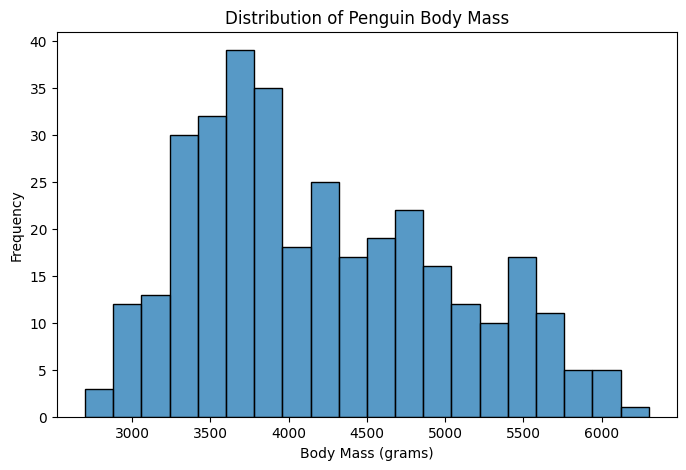

In [12]:
#Task 3 : Histogram: Distribution Shape
plt.figure(figsize=(8, 5))

sns.histplot(x="body_mass_g", data=df, bins=20)

plt.title("Distribution of Penguin Body Mass")
plt.xlabel("Body Mass (grams)")
plt.ylabel("Frequency")

plt.show()
#The body-mass distribution is slightly skewed to the right because its heavier values extend farther toward the right side of the histogram.

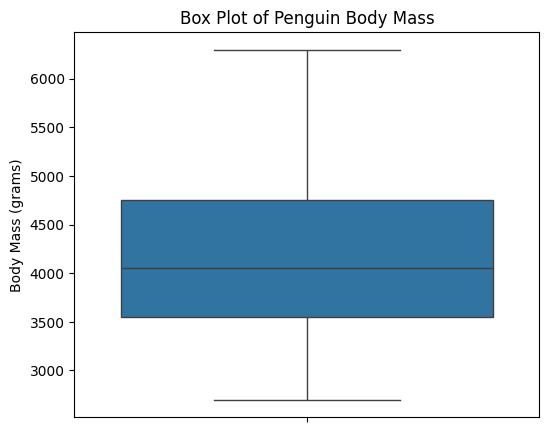

In [13]:
#Task 4 : Box Plot: Visual Outlier Detection
plt.figure(figsize=(6, 5))

sns.boxplot(y="body_mass_g", data=df)

plt.title("Box Plot of Penguin Body Mass")
plt.ylabel("Body Mass (grams)")

plt.show()
#No outlier points appear beyond the whiskers, so the visual outlier count is 0.

In [15]:
#Task 5 : Outlier Detection: The Mechanism (IQR)
Q1 = df["body_mass_g"].quantile(0.25)
Q3 = df["body_mass_g"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["body_mass_g"] < lower) |
    (df["body_mass_g"] > upper)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outliers:", len(outliers))
#The IQR method detected 0 outliers. This matches the visual count from the box plot because no points appeared beyond the whiskers.

Q1: 3550.0
Q3: 4750.0
IQR: 1200.0
Lower bound: 1750.0
Upper bound: 6550.0
Number of outliers: 0


In [17]:
%pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 15.0 MB/s  0:00:024.8 MB/s eta 0:00:01:01
Note: you may need to restart the kernel to use updated packages.


In [19]:
#Task 6 : Outlier Detection: Z-score Comparison
from scipy import stats

df["zscore"] = stats.zscore(
    df["body_mass_g"],
    nan_policy="omit"
)

outliers_z = df[df["zscore"].abs() > 3]

print("Number of Z-score outliers:", len(outliers_z))
#Both IQR and Z-score found 0 outliers, so their results match. The data is slightly right-skewed, but there are no extreme values.

Number of Z-score outliers: 0


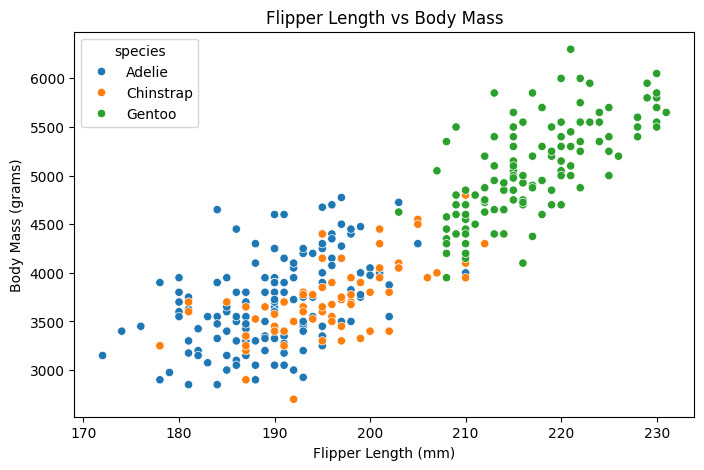

In [20]:
#Task 7: Scatter Plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    data=df
)

plt.title("Flipper Length vs Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (grams)")

plt.show()
#There is a positive relationship: penguins with longer flippers generally have greater body mass.

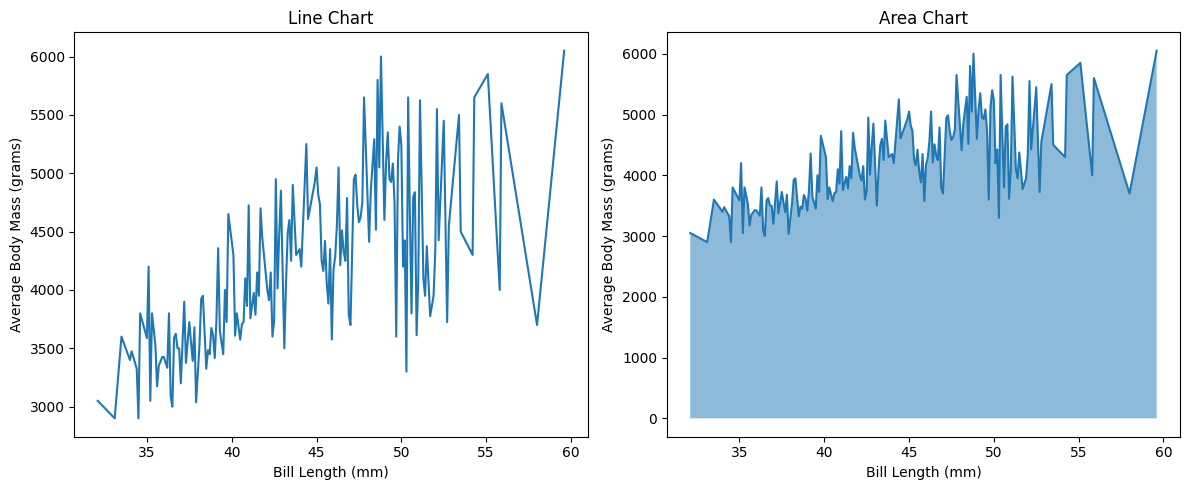

In [21]:
#Task 8 : Line and Area Chart
# Calculate average body mass for each bill length
trend = df.groupby("bill_length_mm")["body_mass_g"].mean().reset_index()
trend = trend.sort_values("bill_length_mm")

# Create line and area charts
plt.figure(figsize=(12, 5))

# Line chart
plt.subplot(1, 2, 1)
plt.plot(trend["bill_length_mm"], trend["body_mass_g"])
plt.title("Line Chart")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Average Body Mass (grams)")

# Area chart
plt.subplot(1, 2, 2)
plt.fill_between(
    trend["bill_length_mm"],
    trend["body_mass_g"],
    alpha=0.5
)
plt.plot(trend["bill_length_mm"], trend["body_mass_g"])
plt.title("Area Chart")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Average Body Mass (grams)")

plt.tight_layout()
plt.show()
#Both charts show the same trend, but the filled area makes the values look larger and more noticeable.

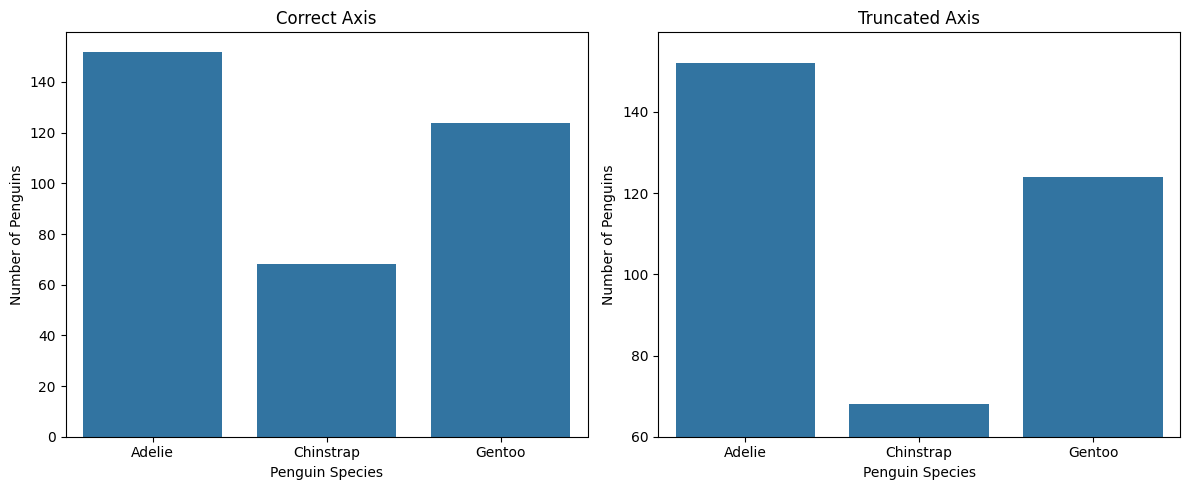

In [22]:
plt.figure(figsize=(12, 5))

# Correct count plot: y-axis starts at zero
plt.subplot(1, 2, 1)
sns.countplot(x="species", data=df)
plt.ylim(bottom=0)
plt.title("Correct Axis")
plt.xlabel("Penguin Species")
plt.ylabel("Number of Penguins")

# Misleading count plot: y-axis starts at 60
plt.subplot(1, 2, 2)
sns.countplot(x="species", data=df)
plt.ylim(bottom=60)
plt.title("Truncated Axis")
plt.xlabel("Penguin Species")
plt.ylabel("Number of Penguins")

plt.tight_layout()
plt.show()